In [ ]:
import numpy as np
import py21cmfast as p21c
from astropy.cosmology import FlatLambdaCDM

# ------------------------------------------------------------------
# USER-DEFINED PARAMETERS (replace with your own values)
# ------------------------------------------------------------------
z_min      = 6.0          # final redshift of the light-cone
z_max      = 10.0         # highest redshift to integrate back to
Ndim       = 128          # HII_DIM
Lbox       = 300.0        # BOX_LEN (comoving Mpc)
n_cpus     = 8            # N_THREADS

# Cosmology
sigma_8   = 0.81
h         = 0.68
omega_0   = 0.31
omega_b   = 0.049
n_s       = 0.965

# Astrophysics
ioneff    = 50.0          # HII_EFF_FACTOR
mfp_ion   = 30.0          # R_BUBBLE_MAX (Mpc)
logLXray  = 40.0          # L_X (erg/s/Hz/SFR)

YHe       = 0.24          # helium mass fraction

# ------------------------------------------------------------------
# 1. Run the light-cone
# ------------------------------------------------------------------
lightcone = p21c.run_lightcone(
    lightcone_quantities=('velocity', 'density', 'xH_box'),
    redshift=z_min,
    max_redshift=z_max,
    cosmo_params=p21c.CosmoParams(
        SIGMA_8=sigma_8, hlittle=h, OMm=omega_0, OMb=omega_b, POWER_INDEX=n_s
    ),
    astro_params=p21c.AstroParams(
        {"HII_EFF_FACTOR": ioneff,
         "R_BUBBLE_MAX":  mfp_ion,
         "L_X":           logLXray}
    ),
    flag_options=p21c.FlagOptions({"USE_TS_FLUCT": True}),
    Y_He=YHe,
    user_params={
        "HII_DIM":               Ndim,
        "BOX_LEN":               Lbox,
        "USE_INTERPOLATION_TABLES": True,
        "N_THREADS":             n_cpus
    },
    random_seed=37,
    direc='_cache'
)

# ------------------------------------------------------------------
# 2. DIAGNOSTICS – confirm object structure
# ------------------------------------------------------------------
print("\n=== LIGHTCONE DIAGNOSTICS ===")
print("Attributes:", sorted(lightcone.__dict__.keys()))
print("Y_He (from global_params):", lightcone.global_params['Y_He'])

# ------------------------------------------------------------------
# 3. Light-cone geometry
# ------------------------------------------------------------------
pos_axis = lightcone.lightcone_distances          # comoving distance [Mpc]
red_axis = lightcone.lightcone_redshifts          # redshift per slice

# Trim to redshift <= z_max
ind_z = np.where(red_axis <= z_max)[0]
pos_axis = pos_axis[ind_z]
red_axis = red_axis[ind_z]

# ------------------------------------------------------------------
# 4. Extract fields
# ------------------------------------------------------------------
density      = lightcone.density[:, :, ind_z] + 1.0   # 1 + δ
xHI          = lightcone.xH_box[:, :, ind_z]        # neutral fraction
v_los_comov  = lightcone.velocity[:, :, ind_z]      # comoving Mpc s⁻¹

# ------------------------------------------------------------------
# 5. Convert velocity to physical km s⁻¹
# ------------------------------------------------------------------
#Mpc_per_s_to_km_per_s = 3.08568e19
#v_pec_km_s = v_los_comov * (1.0 + red_axis[None, None, :]) * Mpc_per_s_to_km_per_s

# ------------------------------------------------------------------
# 6. EXACT H(z) using astropy (Flat ΛCDM)
# ------------------------------------------------------------------
cosmo_astropy = FlatLambdaCDM(H0=100 * h, Om0=omega_0)  # H0 in km/s/Mpc, Om0 = Ω_m
H_z = cosmo_astropy.H(red_axis).value                    # H(z) in km s⁻¹ Mpc⁻¹

# Optional: Print H(z) evolution
print(f"\nH(z) evolution (z = {red_axis.min():.1f} → {red_axis.max():.1f}):")
print(f"   H({red_axis.min():.1f}) = {H_z[0]:.1f} km/s/Mpc")
print(f"   H({red_axis.max():.1f}) = {H_z[-1]:.1f} km/s/Mpc")




=== LIGHTCONE DIAGNOSTICS ===
Attributes: ['_current_index', '_current_redshift', 'astro_params', 'cache_files', 'cosmo_params', 'density', 'flag_options', 'global_brightness_temp', 'global_params', 'global_quantities', 'global_xH', 'lightcone_distances', 'lightcones', 'log10_mturnovers', 'log10_mturnovers_mini', 'node_redshifts', 'photon_nonconservation_data', 'random_seed', 'redshift', 'user_params', 'velocity', 'xH_box']
Y_He (from global_params): 0.24

H(z) evolution (z = 6.0 → 10.0):
   H(6.0) = 703.5 km/s/Mpc
   H(10.0) = 1380.5 km/s/Mpc


In [6]:
# ------------------------------------------------------------------
# 1. All attributes that the LightCone object actually has
# ------------------------------------------------------------------
print("\n=== ALL ATTRIBUTES OF THE LightCone OBJECT ===")
print(sorted(lightcone.__dict__.keys()))
print("Total number of attributes :", len(lightcone.__dict__))

# ------------------------------------------------------------------
# 2. Parameter objects that are stored **as attributes**
# ------------------------------------------------------------------
print("\n=== PARAMETER OBJECTS (attributes) ===")
for name in ['cosmo_params', 'astro_params', 'flag_options', 'user_params']:
    obj = getattr(lightcone, name, None)
    print(f"{name:12s} : {obj}")

# ------------------------------------------------------------------
# 3. Y_He lives inside global_params (not as a top-level attribute)
# ------------------------------------------------------------------
print("\n=== GLOBAL PARAMETERS (including Y_He) ===")
global_params = lightcone.global_params
print("global_params is a dict with", len(global_params), "entries")
print("Y_He :", global_params['Y_He'])          # <-- this is the one you were missing

# ------------------------------------------------------------------
# 4. Light-cone fields that were requested & returned
# ------------------------------------------------------------------
print("\n=== LIGHT-CONE FIELDS THAT WERE REQUESTED & RETURNED ===")
requested = ('velocity', 'density', 'xH_box')
for name in requested:
    arr = getattr(lightcone, name)
    print(f"  {name:12s} -> shape {arr.shape}  dtype {arr.dtype}")

# ------------------------------------------------------------------
# 5. All *possible* light-cone quantities (for reference)
# ------------------------------------------------------------------
print("\n=== ALL POSSIBLE LIGHT-CONE QUANTITIES (from py21cmfast) ===")
possible = [
    'brightness_temp', 'density', 'velocity', 'xH_box',
    'Tk_box', 'Ts_box', 'Gamma12_box', 'temp_kinetic_all_gas'
]
for q in possible:
    print(f"  {q:20s} {'present' if hasattr(lightcone, q) else 'absent'}")


=== ALL ATTRIBUTES OF THE LightCone OBJECT ===
['_current_index', '_current_redshift', 'astro_params', 'cache_files', 'cosmo_params', 'density', 'flag_options', 'global_brightness_temp', 'global_params', 'global_quantities', 'global_xH', 'lightcone_distances', 'lightcones', 'log10_mturnovers', 'log10_mturnovers_mini', 'node_redshifts', 'photon_nonconservation_data', 'random_seed', 'redshift', 'user_params', 'velocity', 'xH_box']
Total number of attributes : 22

=== PARAMETER OBJECTS (attributes) ===
cosmo_params : CosmoParams:
    OMb        : 0.049
    OMm        : 0.31
    POWER_INDEX: 0.965
    SIGMA_8    : 0.81
    hlittle    : 0.68
    
astro_params : AstroParams:
    ALPHA_ESC       : -0.5
    ALPHA_STAR      : 0.5
    ALPHA_STAR_MINI : 0.5
    A_LW            : 2.0
    A_VCB           : 1.0
    BETA_LW         : 0.6
    BETA_VCB        : 1.8
    F_ESC10         : 0.1
    F_ESC7_MINI     : 0.01
    F_H2_SHIELD     : 0.0
    F_STAR10        : 0.05011872336272722
    F_STAR7_MINI 

In [33]:
lcn = p21c.RectilinearLightconer.with_equal_cdist_slices(
    min_redshift=7.0,
    max_redshift=12.0,
    quantities=('brightness_temp', 'density', 'velocity_z', 'xH_box'),
    resolution=user_params.cell_size,
    # index_offset=0,
    get_los_velocity=True,  # Enable this if you want LOS velocity
)


In [34]:
lightcone = p21c.run_lightcone(
    lightconer=lcn,
    global_quantities=("brightness_temp", 'density', 'xH_box'),
    direc='_cache',
    user_params=user_params
)

/home/swanith/.local/lib/python3.10/site-packages/py21cmfast/inputs.py:515: UserWarning: The USE_INTERPOLATION_TABLES setting has changed in v3.1.2 to be default True. You can likely ignore this warning, but if you relied onhaving USE_INTERPOLATION_TABLES=False by *default*, please set it explicitly. To silence this warning, set it explicitly to True. Thiswarning will be removed in v4.
  warnings.warn(


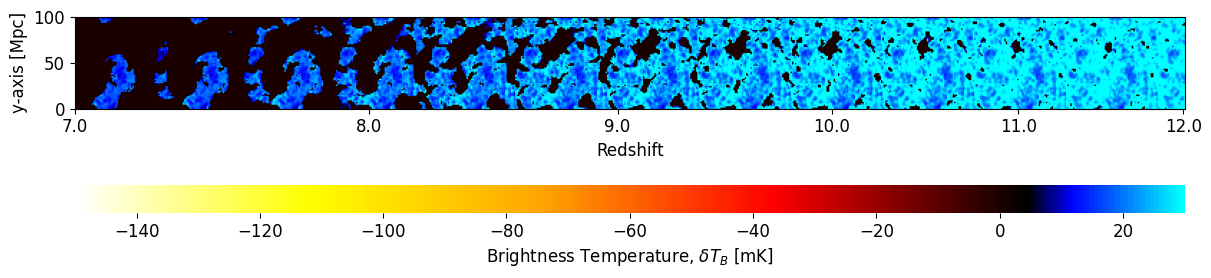

In [35]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6), constrained_layout=True)
plotting.lightcone_sliceplot(lightcone, ax=ax, fig=fig);



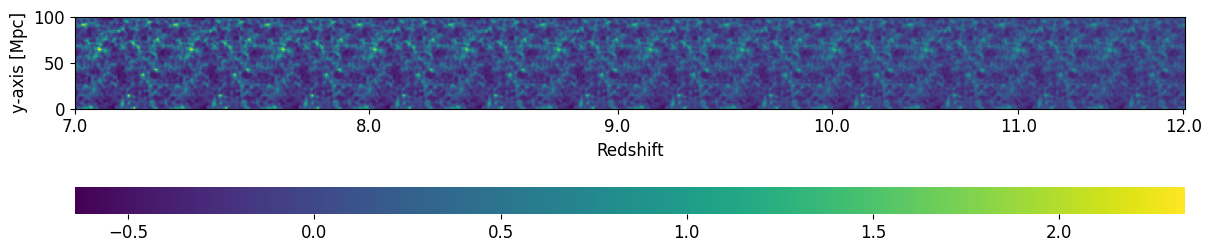

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6), constrained_layout=True)
plotting.lightcone_sliceplot(lightcone, 'density', ax=ax, fig=fig);

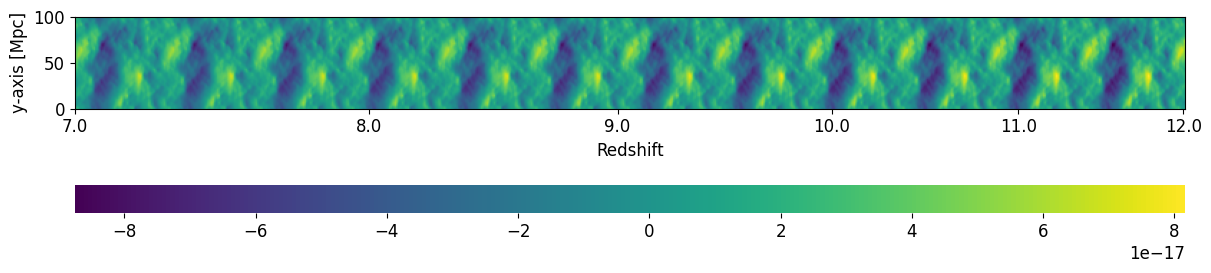

In [31]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6), constrained_layout=True)
plotting.lightcone_sliceplot(lightcone, 'velocity_z', ax=ax, fig=fig);

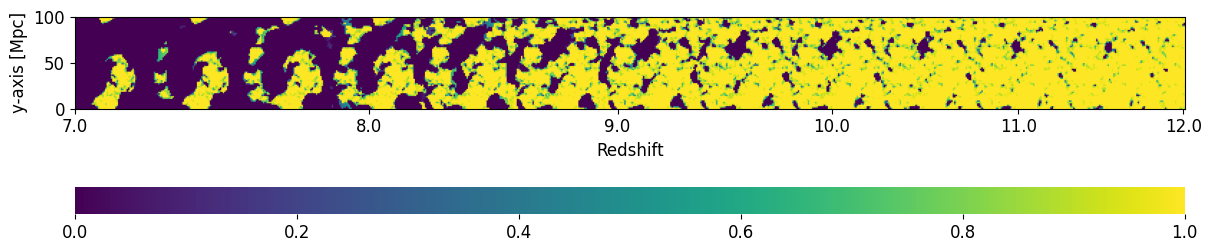

In [32]:
fig, ax = plt.subplots(1, 1, figsize=(12, 6), constrained_layout=True)
plotting.lightcone_sliceplot(lightcone, 'xH_box', ax=ax, fig=fig);

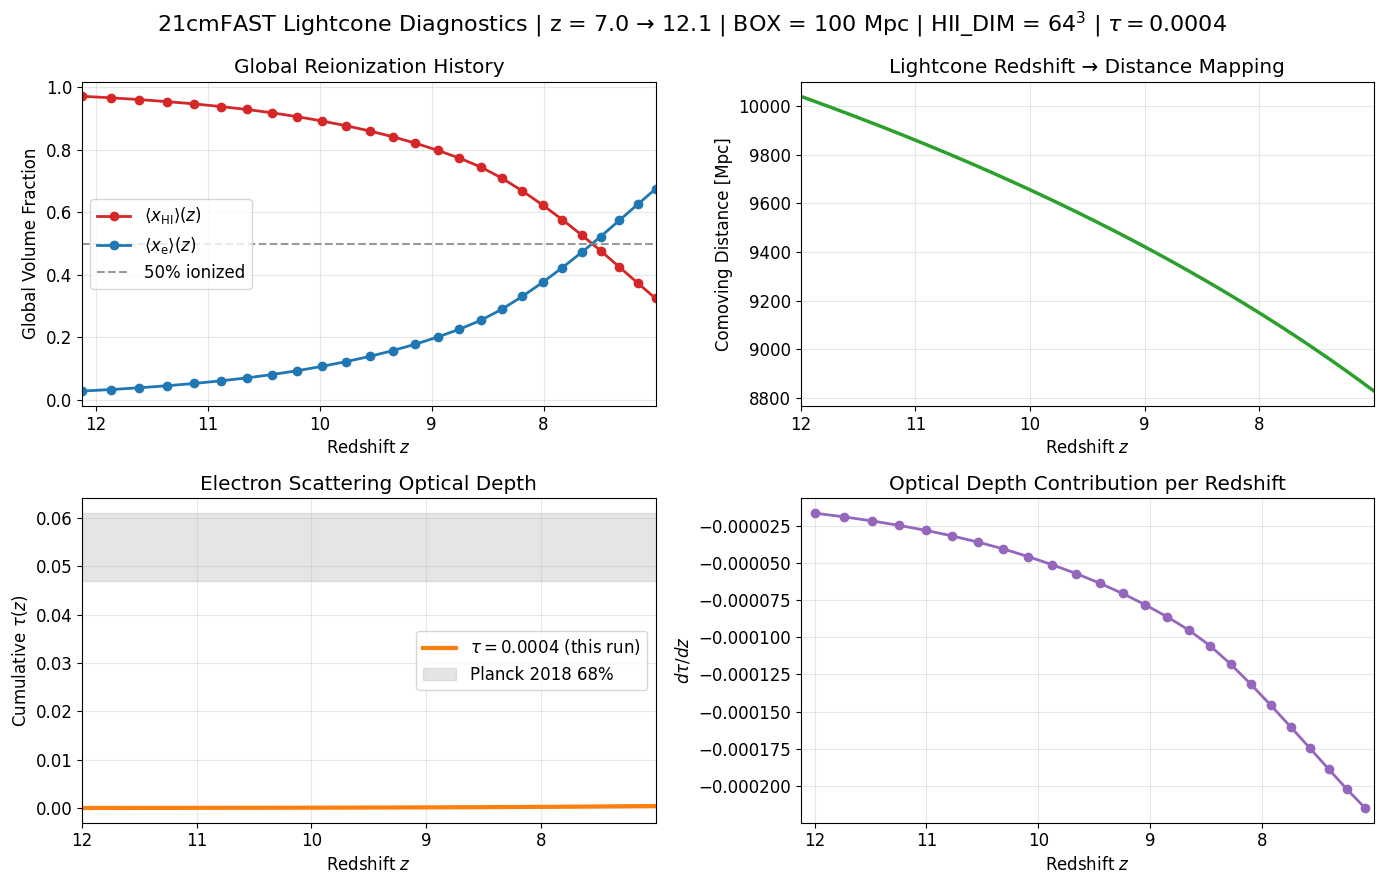

In [94]:
import astropy.units as u
from astropy.cosmology import FlatLambdaCDM

# Build the exact same cosmology as your simulation
cosmo = FlatLambdaCDM(
    H0=100 * lightcone.cosmo_params.hlittle,   # km/s/Mpc
    Om0=lightcone.cosmo_params.OMm,
    Ob0=lightcone.cosmo_params.OMb,
    Tcmb0=2.7255*u.K,          # optional, but good
    Neff=3.046,
    m_nu=[0, 0, 0.06]*u.eV
)


# ------------------------------------------------------------------
# Cosmology from your lightcone
# ------------------------------------------------------------------
cosmo = FlatLambdaCDM(
    H0=100 * lightcone.cosmo_params.hlittle,
    Om0=lightcone.cosmo_params.OMm,
    Ob0=lightcone.cosmo_params.OMb
)

# ------------------------------------------------------------------
# GLOBAL quantities (coarse grid: node_redshifts)
# ------------------------------------------------------------------
z_global   = lightcone.node_redshifts          # shape ~ (26,)
xH_global  = lightcone.global_xH
xe_global  = 1.0 - xH_global
#chi_global = cosmo.comoving_distance(z_global).to(u.Mpc).value   # ← THIS IS GOLD     # fine grid ~ (774,)

# ------------------------------------------------------------------
# FINE lightcone grid (pixel-level)
# ------------------------------------------------------------------
z_fine     = lightcone.lightcone_redshifts     # shape = (774,) — this exists!
chi_global = cosmo.comoving_distance(z_fine).to(u.Mpc).value#chi_fine   = lightcone.lightcone_distances     # same as chi_global, but aligned

# ------------------------------------------------------------------
# Compute τ(z) on the coarse (global) grid — this is correct
# ------------------------------------------------------------------
sigma_T = const.sigma_T.cgs.value
m_p     = const.m_p.cgs.value
rho_c0  = cosmo.critical_density0.to(u.g/u.cm**3).value
n0      = (cosmo.Ob0 * rho_c0) / m_p
Mpc_cm  = 3.08568e24

order = np.argsort(-z_global)
z_s, xe_s, chi_s = z_global[order], xe_global[order], chi_global[order]

dchi = np.diff(chi_s)
dchi = np.insert(dchi, 0, 0.0)
z_mid = 0.5*(z_s[:-1] + z_s[1:])
a_mid = 1.0/(1.0 + z_mid)
xe_mid = 0.5*(xe_s[:-1] + xe_s[1:])

dtau = sigma_T * n0 * xe_mid * (a_mid**-2) * (dchi[1:] * Mpc_cm)
tau_global = np.cumsum(dtau)
tau_global = np.insert(tau_global, 0, 0.0)
tau_global = tau_global[np.argsort(order)]

# ------------------------------------------------------------------
# Plotting — now with correct arrays!
# ------------------------------------------------------------------
plt.figure(figsize=(14, 9))

# 1. Ionization history (coarse grid)
plt.subplot(2, 2, 1)
plt.plot(z_global, xH_global, 'C3-o', ms=6, lw=2, label=r'$\langle x_{\rm HI} \rangle(z)$')
plt.plot(z_global, xe_global, 'C0-o', ms=6, lw=2, label=r'$\langle x_{\rm e} \rangle(z)$')
plt.axhline(0.5, color='gray', ls='--', alpha=0.8, label='50% ionized')
plt.xlabel('Redshift $z$')
plt.ylabel('Global Volume Fraction')
plt.title('Global Reionization History')
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(z_global.max(), z_global.min())

# 2. Lightcone geometry (fine grid)
plt.subplot(2, 2, 2)
plt.plot(z_fine, chi_global, 'C2-', lw=2.5)
plt.xlabel('Redshift $z$')
plt.ylabel('Comoving Distance [Mpc]')
plt.title('Lightcone Redshift → Distance Mapping')
plt.grid(alpha=0.3)
plt.xlim(z_fine.max(), z_fine.min())

# 3. Optical depth τ(z) — interpolated to fine grid for smooth plot
plt.subplot(2, 2, 3)
tau_fine = np.interp(z_fine[::-1], z_global[::-1], tau_global[::-1])[::-1]  # align & interp
plt.plot(z_fine, tau_fine, 'C1-', lw=3, label=rf'$\tau = {tau_global[-1]:.4f}$ (this run)')
plt.axhspan(0.047, 0.061, color='gray', alpha=0.2, label='Planck 2018 68%')
plt.xlabel('Redshift $z$')
plt.ylabel('Cumulative $\\tau(z)$')
plt.title('Electron Scattering Optical Depth')
plt.legend()
plt.grid(alpha=0.3)
plt.xlim(z_fine.max(), z_fine.min())

# 4. dτ/dz — where the optical depth comes from
plt.subplot(2, 2, 4)
dtau_dz = np.diff(tau_global) / np.diff(z_global)
z_dtau = 0.5*(z_global[:-1] + z_global[1:])
plt.plot(z_dtau, dtau_dz, 'C4-o', ms=6, lw=2)
plt.xlabel('Redshift $z$')
plt.ylabel('$d\\tau / dz$')
plt.title('Optical Depth Contribution per Redshift')
plt.grid(alpha=0.3)
plt.xlim(z_global.max(), z_global.min())

# Global title
plt.suptitle(f'21cmFAST Lightcone Diagnostics | '
             f'z = {lightcone.redshift:.1f} → {z_global.max():.1f} | '
             f'BOX = {lightcone.user_params.BOX_LEN:.0f} Mpc | '
             f'HII_DIM = {lightcone.user_params.HII_DIM}$^3$ | '
             f'$\\tau = {tau_global[-1]:.4f}$',
             fontsize=16, y=0.98)

plt.tight_layout()
plt.show()

kSZ signal in K:
  Mean: -2.1074e-05 K
  Std: 1.8649e-03 K
  Min: -3.4080e-02 K
  Max: 2.7294e-02 K
  RMS: 1.8650e-03 K


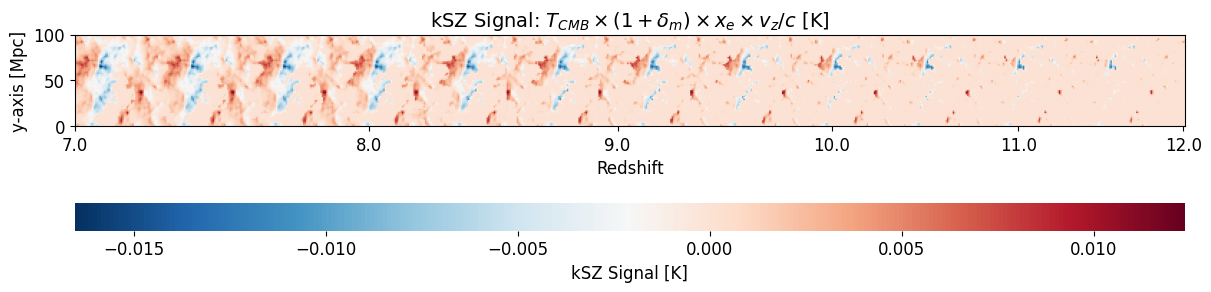

In [ ]:
# Calculate kSZ in μK
#T_CMB = 1#2.7255  # K (CMB temperature)
#T_CMB_uK = 1#T_CMB * 1e6  # μK

kSZ_product = (1 + density) * x_e * v_los_km_s / c_km_s
#kSZ_uK = kSZ_product * T_CMB_uK  # Convert to μK

print(f"kSZ signal in K:")
print(f"  Mean: {kSZ_uK.mean():.4e} K")
print(f"  Std: {kSZ_uK.std():.4e} K")
print(f"  Min: {kSZ_uK.min():.4e} K")
print(f"  Max: {kSZ_uK.max():.4e} K")
print(f"  RMS: {np.sqrt(np.mean(kSZ_uK**2)):.4e} K")

# Add it to the lightcone object
lightcone.kSZ_uK = kSZ_uK

# Plot it with red-blue colormap
fig, ax = plt.subplots(1, 1, figsize=(12, 6), constrained_layout=True)

# We need to manually set the colormap since lightcone_sliceplot has defaults
# Let's check what the function does and override if needed
from matplotlib import pyplot as plt

# Use the plotting function but we'll modify the colorbar label after
plotting.lightcone_sliceplot(lightcone, 'kSZ_uK', ax=ax, fig=fig)

# Update the colormap to RdBu_r (red-blue reversed, so red is positive)
# We need to access the image and update it
for child in ax.get_children():
    if hasattr(child, 'set_cmap'):
        child.set_cmap('RdBu_r')
        
# Update the colorbar label
cbar = fig.get_axes()[-1]  # The colorbar is typically the last axis
cbar.set_xlabel(r'kSZ Signal [K]', fontsize=12)

ax.set_title(r'kSZ Signal: $T_{CMB} \times (1+\delta_m) \times x_e \times v_z / c$ [K]', 
             fontsize=14)

plt.savefig('kSZ_signal_K.png', dpi=150, bbox_inches='tight')
plt.show()

Target redshift: 10.0
Closest slice: z = 10.001 (index 528)


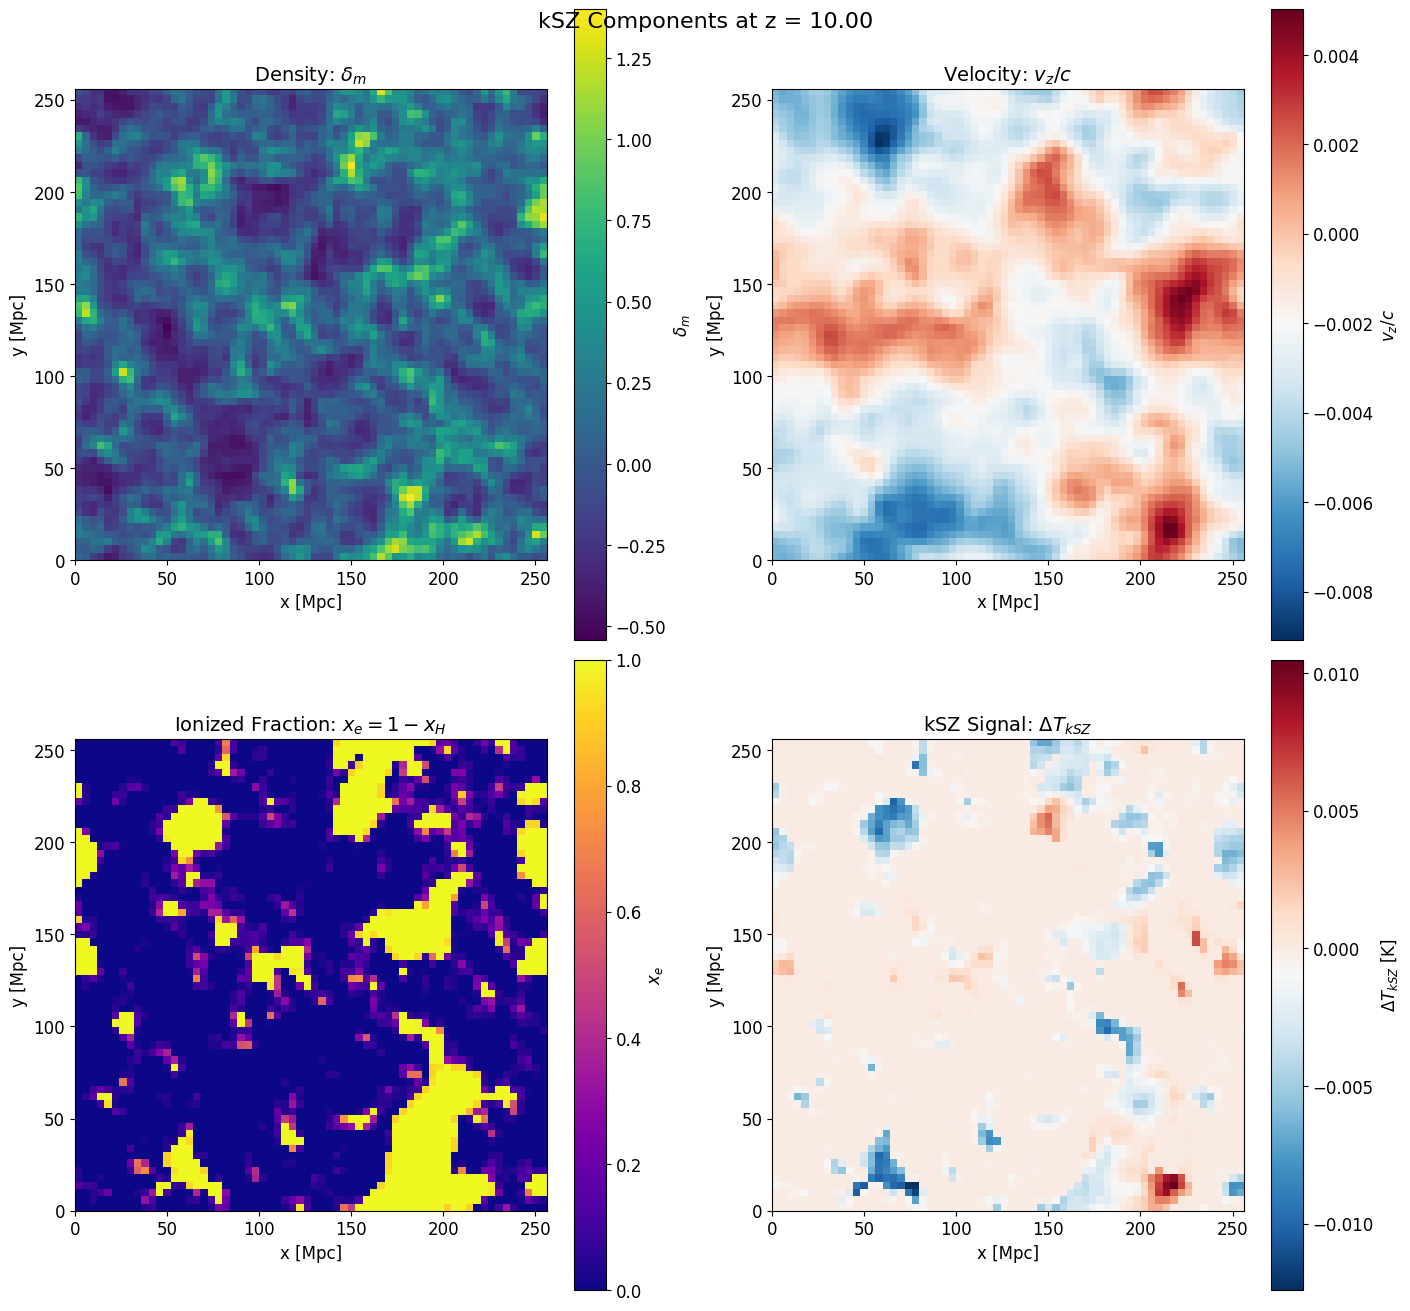


✓ Collage saved: kSZ_collage_z10.0.png

Field statistics at z = 10.001:
  δ_m:    mean=0.078, std=0.290
  v_z/c:  mean=-1.8552e-03, std=2.2410e-03
  x_e:    mean=0.205, std=0.371
  ΔT_kSZ: mean=-4.2366e-04 K, std=1.6461e-03 K


In [109]:
import numpy as np
import matplotlib.pyplot as plt

# Find the redshift slice closest to z=10
z_array = lcn.lc_redshifts
target_z = 10.0
z_idx = np.argmin(np.abs(z_array - target_z))
actual_z = z_array[z_idx]

print(f"Target redshift: {target_z}")
print(f"Closest slice: z = {actual_z:.3f} (index {z_idx})")

# Extract 2D slices at this redshift
density_slice = density[:, :, z_idx]
x_e_slice = x_e[:, :, z_idx]
v_over_c_slice = v_los_km_s[:, :, z_idx] / c_km_s
kSZ_slice = kSZ_uK[:, :, z_idx]

# Get the box size for axis labels
box_size = user_params.BOX_LEN  # Mpc

# Create the 2×2 collage
fig, axes = plt.subplots(2, 2, figsize=(14, 13), constrained_layout=True)

# 1. Density field (δ_m)
im1 = axes[0, 0].imshow(density_slice, 
                        origin='lower',
                        extent=[0, box_size, 0, box_size],
                        cmap='viridis',
                        interpolation='nearest')
axes[0, 0].set_xlabel('x [Mpc]', fontsize=12)
axes[0, 0].set_ylabel('y [Mpc]', fontsize=12)
axes[0, 0].set_title(r'Density: $\delta_m$', fontsize=14)
cbar1 = fig.colorbar(im1, ax=axes[0, 0])
cbar1.set_label(r'$\delta_m$', fontsize=12)

# 2. Velocity (v_z / c)
im2 = axes[0, 1].imshow(v_over_c_slice, 
                        origin='lower',
                        extent=[0, box_size, 0, box_size],
                        cmap='RdBu_r',
                        interpolation='nearest')
axes[0, 1].set_xlabel('x [Mpc]', fontsize=12)
axes[0, 1].set_ylabel('y [Mpc]', fontsize=12)
axes[0, 1].set_title(r'Velocity: $v_z / c$', fontsize=14)
cbar2 = fig.colorbar(im2, ax=axes[0, 1])
cbar2.set_label(r'$v_z / c$', fontsize=12)

# 3. Ionization fraction (x_e)
im3 = axes[1, 0].imshow(x_e_slice, 
                        origin='lower',
                        extent=[0, box_size, 0, box_size],
                        cmap='plasma',
                        interpolation='nearest',
                        vmin=0, vmax=1)
axes[1, 0].set_xlabel('x [Mpc]', fontsize=12)
axes[1, 0].set_ylabel('y [Mpc]', fontsize=12)
axes[1, 0].set_title(r'Ionized Fraction: $x_e = 1 - x_H$', fontsize=14)
cbar3 = fig.colorbar(im3, ax=axes[1, 0])
cbar3.set_label(r'$x_e$', fontsize=12)

# 4. kSZ signal (ΔT in μK)
im4 = axes[1, 1].imshow(kSZ_slice, 
                        origin='lower',
                        extent=[0, box_size, 0, box_size],
                        cmap='RdBu_r',
                        interpolation='nearest')
axes[1, 1].set_xlabel('x [Mpc]', fontsize=12)
axes[1, 1].set_ylabel('y [Mpc]', fontsize=12)
axes[1, 1].set_title(r'kSZ Signal: $\Delta T_{kSZ}$', fontsize=14)
cbar4 = fig.colorbar(im4, ax=axes[1, 1])
cbar4.set_label(r'$\Delta T_{kSZ}$ [K]', fontsize=12)

# Overall title
fig.suptitle(f'kSZ Components at z = {actual_z:.2f}', fontsize=16, y=0.995)

plt.savefig(f'kSZ_collage_z{actual_z:.1f}.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Collage saved: kSZ_collage_z{actual_z:.1f}.png")

# Print statistics
print(f"\nField statistics at z = {actual_z:.3f}:")
print(f"  δ_m:    mean={density_slice.mean():.3f}, std={density_slice.std():.3f}")
print(f"  v_z/c:  mean={v_over_c_slice.mean():.4e}, std={v_over_c_slice.std():.4e}")
print(f"  x_e:    mean={x_e_slice.mean():.3f}, std={x_e_slice.std():.3f}")
print(f"  ΔT_kSZ: mean={kSZ_slice.mean():.4e} K, std={kSZ_slice.std():.4e} K")

In [2]:
# =============================================================================
# LIGHTCONE GENERATION - MINIMAL & CLEAN VERSION
# py21cmfast v3.4
# =============================================================================

# =============================================================================
# CELL 1: Imports
# =============================================================================
import numpy as np
import matplotlib as mpl
#matplotlib.use('Agg')  # Use non-interactive backend
import matplotlib.pyplot as plt
import py21cmfast as p21c
from py21cmfast import plotting

import os
from datetime import datetime

print(f"py21cmfast version: {p21c.__version__}")

# =============================================================================
# CELL 1a0: Create Output Directory for Plots
# =============================================================================
plot_dir = "1DEC_lightcone_plots_v3/test_small_box"

# Create directory if it doesn't exist
if not os.path.exists(plot_dir):
    os.makedirs(plot_dir)
    print(f"Created directory: {plot_dir}")
else:
    print(f"Directory already exists: {plot_dir}")

print(f"All plots will be saved to: {os.path.abspath(plot_dir)}")


# =============================================================================
# Standardized Plot Settings
# =============================================================================

plt.rcParams.update({
    # Font settings
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset': 'cm',  # Computer Modern (LaTeX standard)
    'font.size': 20,
    'axes.labelsize': 20,
    'axes.titlesize': 20,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 20,
    'figure.titlesize': 20,
    
    # Professional ticks
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 6,
    'ytick.major.size': 6,
    'xtick.minor.size': 3,
    'ytick.minor.size': 3,
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'xtick.minor.width': 0.8,
    'ytick.minor.width': 0.8,
    'xtick.top': True,
    'ytick.right': True,
    
    # Line and axes
    'axes.linewidth': 1.0,
    'lines.linewidth': 1.8,
    'lines.markersize': 5,
    
    # Grid
    'grid.linewidth': 0.5,
    'grid.alpha': 0.3,
    
    # Figure
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.05,
})

# Enable minor ticks globally
mpl.rcParams['xtick.minor.visible'] = True
mpl.rcParams['ytick.minor.visible'] = True

print("✓ Plot settings applied")


# =============================================================================
# CELL 1a: Define Minimal User Parameters
# Only specify what differs from defaults or what's required
# =============================================================================

# Basic simulation parameters
user_params = p21c.UserParams(
    HII_DIM=32,                      # Resolution of ionization/spin-temp grids
    BOX_LEN=100.0,                    # Box size in comoving Mpc
    USE_INTERPOLATION_TABLES=True,    # Speed up calculations
    N_THREADS=8                       # Number of CPU threads
)

# Redshift range for the lightcone
z_min = 5.0                           # Final/lowest redshift
z_max = 20.0                          # Highest redshift to simulate

print("User parameters defined:")
print(user_params)


# =============================================================================
# CELL 1b : Print Default Parameters (Optional - for reference)
# See what py21cmfast uses by default if you don't specify
# =============================================================================

print("\n=== DEFAULT COSMOLOGY ===")
print(p21c.CosmoParams())

print("\n=== DEFAULT ASTROPHYSICS ===")
print(p21c.AstroParams())

print("\n=== DEFAULT FLAGS ===")
print(p21c.FlagOptions())





py21cmfast version: 3.4.0
Directory already exists: 1DEC_lightcone_plots_v3/test_small_box
All plots will be saved to: /home/swanith/Desktop/Project2/Plots/Lightconer_v3_v4/1DEC_lightcone_plots_v3/test_small_box
✓ Plot settings applied
User parameters defined:
UserParams:
    BOX_LEN                 : 100.0
    DIM                     : 96
    FAST_FCOLL_TABLES       : False
    HII_DIM                 : 32
    HMF                     : 1
    KEEP_3D_VELOCITIES      : False
    MINIMIZE_MEMORY         : False
    NON_CUBIC_FACTOR        : 1.0
    NO_RNG                  : False
    N_THREADS               : 8
    PERTURB_ON_HIGH_RES     : False
    POWER_SPECTRUM          : 0
    USE_2LPT                : True
    USE_FFTW_WISDOM         : False
    USE_INTERPOLATION_TABLES: True
    USE_RELATIVE_VELOCITIES : False
    

=== DEFAULT COSMOLOGY ===
CosmoParams:
    OMb        : 0.04897468161869667
    OMm        : 0.30964144154550644
    POWER_INDEX: 0.9665
    SIGMA_8    : 0.8102
    hl


=== RUNNING LIGHTCONE ===
Redshift range: z = 5.0 → 20.0
Box size: 100.0 Mpc
Resolution: 32³ cells

Lightcone simulation complete!
Lightcone shape: (32, 32, 965)
Number of redshift slices: 965

=== LIGHTCONE CONTENTS ===
Redshift axis: z ∈ [5.00, 20.03]
Comoving distance axis: r ∈ [7946.5 Mpc, 10959.0 Mpc] Mpc

Available fields:
  brightness_temp      -> shape (32, 32, 965), dtype float32
  density              -> shape (32, 32, 965), dtype float32
  xH_box               -> shape (32, 32, 965), dtype float32
  velocity             -> shape (32, 32, 965), dtype float32

Trimmed axes:
  Redshift: 964 slices from z=5.00 to z=19.99
  Distance: 7946.5 Mpc to 10955.8 Mpc Mpc
Saved: brightness_temp_lightcone


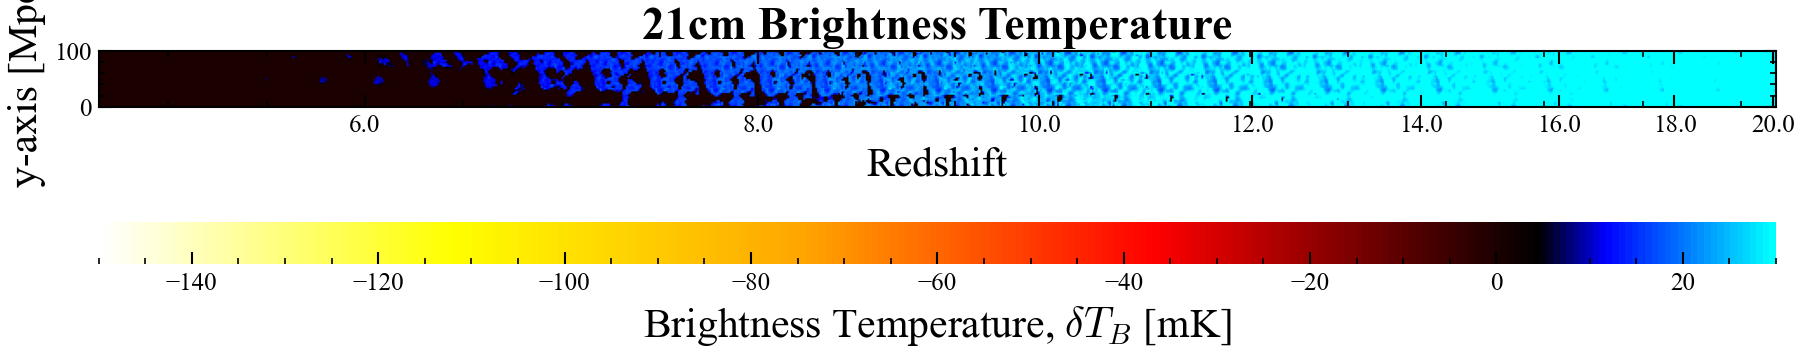

Saved: density_lightcone


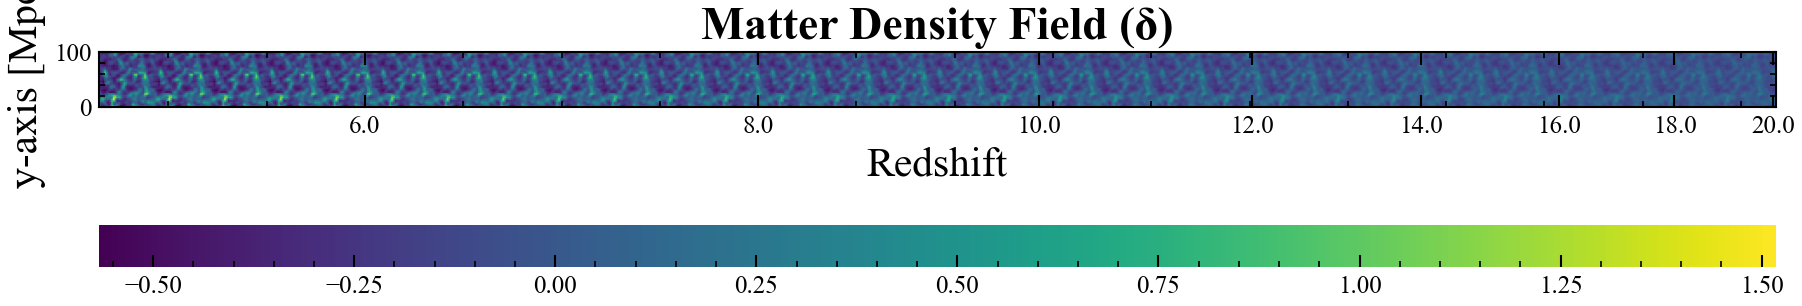

Saved: velocity_z_lightcone


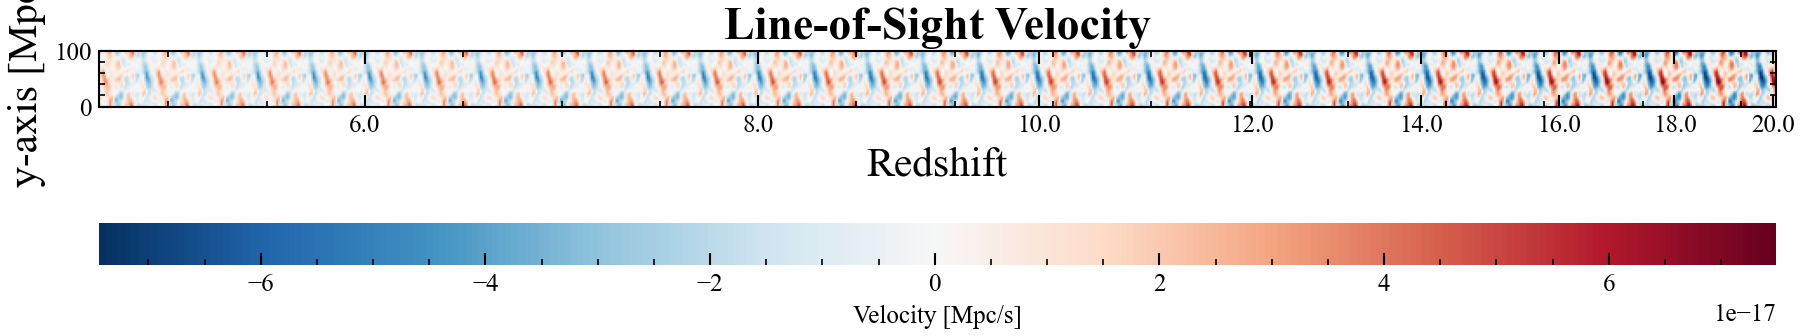

Saved: xHI_lightcone


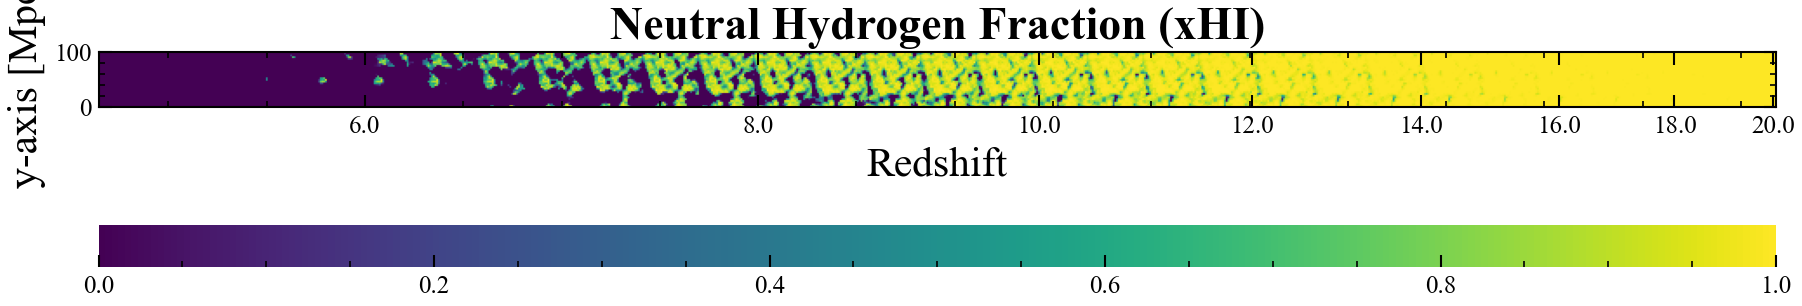


=== ALL PLOTS SAVED ===
Location: /home/swanith/Desktop/Project2/Plots/Lightconer_v3_v4/1DEC_lightcone_plots_v3/test_small_box
Files created:
  - brightness_temp_lightcone.pdf
  - brightness_temp_lightcone.png
  - comoving_distance_vs_z.pdf
  - comoving_distance_vs_z.png
  - density_lightcone.pdf
  - density_lightcone.png
  - global_xHI_vs_redshift.pdf
  - global_xHI_vs_redshift.png
  - kSZ_integrand_lightcone.pdf
  - kSZ_integrand_lightcone.png
  - velocity_z_lightcone.pdf
  - velocity_z_lightcone.png
  - xHI_lightcone.pdf
  - xHI_lightcone.png


In [3]:
# =============================================================================
# CELL 2: Run Lightcone Simulation
# Using defaults for cosmo/astro/flags - only override if needed
# =============================================================================

print("\n=== RUNNING LIGHTCONE ===")
print(f"Redshift range: z = {z_min} → {z_max}")
print(f"Box size: {user_params.BOX_LEN} Mpc")
print(f"Resolution: {user_params.HII_DIM}³ cells")

lightcone = p21c.run_lightcone(
    redshift=z_min,                           # Final redshift
    max_redshift=z_max,                       # Starting redshift
    lightcone_quantities=('brightness_temp', 'density', 'xH_box', 'velocity'),
    #global_quantities=('xH_box'),
    user_params=user_params,
    random_seed=37,                           # For reproducibility
    direc='_cache'                            # Cache directory
)

print("\nLightcone simulation complete!")
print(f"Lightcone shape: {lightcone.brightness_temp.shape}")
print(f"Number of redshift slices: {len(lightcone.lightcone_redshifts)}")


# =============================================================================
# CELL 2a: Inspect Lightcone Structure
# What fields are available and their shapes
# =============================================================================

print("\n=== LIGHTCONE CONTENTS ===")
print(f"Redshift axis: z ∈ [{lightcone.lightcone_redshifts.min():.2f}, "
      f"{lightcone.lightcone_redshifts.max():.2f}]")
print(f"Comoving distance axis: r ∈ [{lightcone.lightcone_distances.min():.1f}, "
      f"{lightcone.lightcone_distances.max():.1f}] Mpc")

print("\nAvailable fields:")
for field in ['brightness_temp', 'density', 'xH_box', 'velocity']:
    if hasattr(lightcone, field):
        data = getattr(lightcone, field)
        print(f"  {field:20s} -> shape {data.shape}, dtype {data.dtype}")


# =============================================================================
# CELL 2b: Extract Redshift and Distance Axes
# Trim to the requested redshift range if needed
# =============================================================================

# Full axes from lightcone
red_axis = lightcone.lightcone_redshifts      # Redshift per slice
pos_axis = lightcone.lightcone_distances      # Comoving distance [Mpc]

# Trim to z <= z_max (in case simulation went slightly beyond)
ind_z = np.where(red_axis <= z_max)[0]
red_axis = red_axis[ind_z]
pos_axis = pos_axis[ind_z]

print(f"\nTrimmed axes:")
print(f"  Redshift: {len(red_axis)} slices from z={red_axis.min():.2f} to z={red_axis.max():.2f}")
print(f"  Distance: {pos_axis.min():.1f} to {pos_axis.max():.1f} Mpc")


# =============================================================================
# CELL 2c1: PLOT 1 - Brightness Temperature (21cm signal)
# Default quantity for 21cm observations
# =============================================================================

fig, ax = plt.subplots(1, 1, figsize=(12, 6), constrained_layout=True)
plotting.lightcone_sliceplot(
    lightcone, 
    'brightness_temp',  # 21cm brightness temperature [mK]
    ax=ax, 
    fig=fig
)
#ax.set_title('21cm Brightness Temperature', fontsize=14, fontweight='bold')

# Save PDF without title
plot_name = "brightness_temp_lightcone"
fig.savefig(f"{plot_dir}/{plot_name}.pdf", bbox_inches='tight')

# Add title for PNG
ax.set_title('21cm Brightness Temperature', fontsize=22, fontweight='bold')
fig.savefig(f"{plot_dir}/{plot_name}.png", dpi=300, bbox_inches='tight')

print(f"Saved: {plot_name}")
plt.show()


# =============================================================================
# CELL 2c2: PLOT 2 - Density Field
# Matter overdensity (δ)
# =============================================================================

fig, ax = plt.subplots(1, 1, figsize=(12, 6), constrained_layout=True)
plotting.lightcone_sliceplot(
    lightcone, 
    'density',          # Density field (δ)
    ax=ax, 
    fig=fig
)
# Save PDF without title
plot_name = "density_lightcone"
fig.savefig(f"{plot_dir}/{plot_name}.pdf", bbox_inches='tight')

# Add title for PNG
ax.set_title('Matter Density Field (δ)', fontsize=22, fontweight='bold')
fig.savefig(f"{plot_dir}/{plot_name}.png", dpi=300, bbox_inches='tight')

print(f"Saved: {plot_name}")
plt.show()

# =============================================================================
# CELL 2c3: PLOT 3 - Line-of-Sight Velocity
# Peculiar velocity along the z-axis
# =============================================================================

fig, ax = plt.subplots(1, 1, figsize=(12, 6), constrained_layout=True)
plotting.lightcone_sliceplot(
    lightcone, 
    'velocity',         # Velocity along line-of-sight [comoving km/s]
    ax=ax, 
    fig=fig
)

# Change colormap after the plot is created
im = ax.images[0]  # Get the image object
im.set_cmap('RdBu_r')  # Set new colormap

#ax.set_title('LOS-Velocity (Mpc/s)', fontsize=14, fontweight='bold')

# Add horizontal label to colorbar (below it)
cbar = fig.get_axes()[-1]  # Get the colorbar axis
cbar.set_xlabel('Velocity [Mpc/s]', fontsize=12)

# Save the plot
# Save PDF without title
plot_name = "velocity_z_lightcone"
fig.savefig(f"{plot_dir}/{plot_name}.pdf", bbox_inches='tight')

# Add title for PNG
ax.set_title('Line-of-Sight Velocity', fontsize=22, fontweight='bold')
fig.savefig(f"{plot_dir}/{plot_name}.png", dpi=300, bbox_inches='tight')

print(f"Saved: {plot_name}")
plt.show()

# =============================================================================
# CELL 2c4: PLOT 4 - Neutral Fraction
# Fraction of neutral hydrogen (xHI)
# =============================================================================

fig, ax = plt.subplots(1, 1, figsize=(12, 6), constrained_layout=True)
plotting.lightcone_sliceplot(
    lightcone, 
    'xH_box',           # Neutral hydrogen fraction
    ax=ax, 
    fig=fig
)
# Save PDF without title
plot_name = "xHI_lightcone"
fig.savefig(f"{plot_dir}/{plot_name}.pdf", bbox_inches='tight')

# Add title for PNG
ax.set_title('Neutral Hydrogen Fraction (xHI)', fontsize=22, fontweight='bold')
fig.savefig(f"{plot_dir}/{plot_name}.png", dpi=300, bbox_inches='tight')

print(f"Saved: {plot_name}")
plt.show()
# =============================================================================
# Summary
# =============================================================================
print(f"\n=== ALL PLOTS SAVED ===")
print(f"Location: {os.path.abspath(plot_dir)}")
print(f"Files created:")
for fname in sorted(os.listdir(plot_dir)):
    print(f"  - {fname}")

In [4]:
# =============================================================================
# CELL 3: Extract 3D Fields (if needed for further analysis)
# Trimmed to the redshift range of interest
# =============================================================================

# Extract fields with proper indexing
brightness_temp = lightcone.brightness_temp[:, :, ind_z]  # [mK]
density_field   = 1+ lightcone.density[:, :, ind_z]          # 1 + δ
neutral_frac    = lightcone.xH_box[:, :, ind_z]           # xHI
velocity_los    = 1e17*lightcone.velocity[:, :, ind_z]         # [comoving km/s]

print("\n=== EXTRACTED 3D FIELDS ===")
print(f"Brightness temperature: {brightness_temp.shape}")
print(f"Density field:          {density_field.shape}")
print(f"Neutral fraction:       {neutral_frac.shape}")
print(f"Velocity:               {velocity_los.shape}")


# =============================================================================
# CELL 3a: Summary Statistics (Optional)
# Quick overview of the simulation results
# =============================================================================

print("\n=== SUMMARY STATISTICS ===")
print(f"Brightness temperature: min={brightness_temp.min():.1f} mK, "
      f"max={brightness_temp.max():.1f} mK, mean={brightness_temp.mean():.1f} mK")
print(f"Neutral fraction:       min={neutral_frac.min():.3f}, "
      f"max={neutral_frac.max():.3f}, mean={neutral_frac.mean():.3f}")
print(f"Density (1+δ):          min={density_field.min():.3f}, "
      f"max={density_field.max():.3f}, mean={density_field.mean():.3f}")
print(f"Velocity_z (1e-17 Mpc/s):          min={velocity_los.min():.3f}, "
      f"max={velocity_los.max():.3f}, mean={velocity_los.mean():.3f}")

# =============================================================================
# NOTES ON CUSTOMIZATION:
# 
# If you want to change cosmology/astrophysics from defaults, add:
#
#   cosmo_params = p21c.CosmoParams(
#       SIGMA_8=0.81,      # Matter power spectrum normalization
#       hlittle=0.68,      # Hubble parameter h
#       OMm=0.31,          # Total matter density
#       OMb=0.049,         # Baryon density
#       POWER_INDEX=0.965  # Primordial spectral index n_s
#   )
#
#   astro_params = p21c.AstroParams(
#       HII_EFF_FACTOR=30.0,  # Ionization efficiency
#       R_BUBBLE_MAX=30.0,    # Maximum bubble size [Mpc]
#       L_X=1e40              # X-ray luminosity per SFR
#   )
#
#   flag_options = p21c.FlagOptions(
#       USE_TS_FLUCT=True     # Include spin temperature fluctuations
#   )
#
# Then pass them to run_lightcone():
#   lightcone = p21c.run_lightcone(
#       ...,
#       cosmo_params=cosmo_params,
#       astro_params=astro_params,
#       flag_options=flag_options
#   )
# =============================================================================


=== EXTRACTED 3D FIELDS ===
Brightness temperature: (32, 32, 964)
Density field:          (32, 32, 964)
Neutral fraction:       (32, 32, 964)
Velocity:               (32, 32, 964)

=== SUMMARY STATISTICS ===
Brightness temperature: min=0.0 mK, max=65.6 mK, mean=18.3 mK
Neutral fraction:       min=0.000, max=1.000, mean=0.607
Density (1+δ):          min=0.312, max=3.738, mean=1.000
Velocity_z (1e-17 Mpc/s):          min=-10.251, max=10.671, mean=0.003


Speed of light: c = 9.715612e-15 Mpc/s

=== kSZ INTEGRAND STATISTICS ===
  Mean: 3.0112e-06
  Std:  1.3107e-03
  Min:  -1.6033e-02
  Max:  1.5118e-02
  RMS:  1.3107e-03
Saved: kSZ_integrand_lightcone


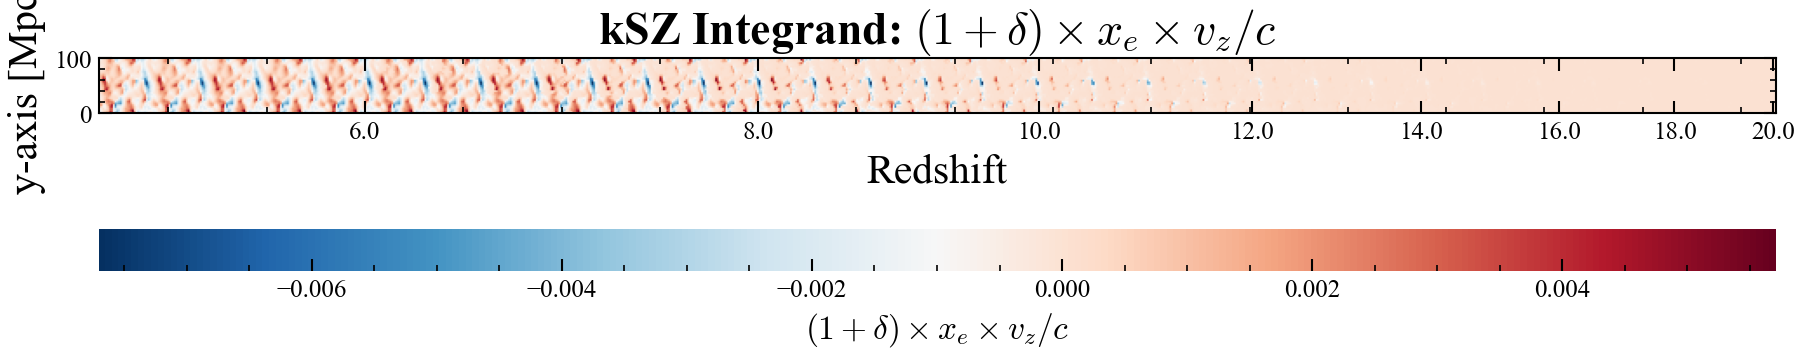

In [5]:
# =============================================================================
# CELL 4: Compute kSZ Integrand
# kSZ integrand = (1 + δ) × x_e × v_z / c
# (T_CMB factor excluded for now, will add after redshift correction)
# =============================================================================

# Extract fields (already trimmed to ind_z)
density_1plus = 1 + lightcone.density[:, :, ind_z]  # 1 + δ
x_e = 1 - lightcone.xH_box[:, :, ind_z]             # Ionized fraction
v_los_Mpc_s = lightcone.velocity[:, :, ind_z]    # Velocity in Mpc/s

# Speed of light in Mpc/s
# c = 299792.458 km/s = 299792.458 km/s × (1 Mpc / 3.08567758e19 km)
c_Mpc_s = 299792.458 / 3.08567758e19  # Mpc/s
print(f"Speed of light: c = {c_Mpc_s:.6e} Mpc/s")

# Compute kSZ integrand (dimensionless)
kSZ_integrand = density_1plus * x_e * v_los_Mpc_s / c_Mpc_s

print(f"\n=== kSZ INTEGRAND STATISTICS ===")
print(f"  Mean: {kSZ_integrand.mean():.4e}")
print(f"  Std:  {kSZ_integrand.std():.4e}")
print(f"  Min:  {kSZ_integrand.min():.4e}")
print(f"  Max:  {kSZ_integrand.max():.4e}")
print(f"  RMS:  {np.sqrt(np.mean(kSZ_integrand**2)):.4e}")

# Add to lightcone object for easy access
lightcone.kSZ_integrand = kSZ_integrand

# =============================================================================
# CELL 4a: PLOT - kSZ Integrand
# =============================================================================

fig, ax = plt.subplots(1, 1, figsize=(12, 6), constrained_layout=True)
plotting.lightcone_sliceplot(lightcone, 'kSZ_integrand', ax=ax, fig=fig)

# Change colormap to RdBu_r (red for positive, blue for negative)
im = ax.images[0]
im.set_cmap('RdBu_r')

# Add colorbar label
cbar = fig.get_axes()[-1]
cbar.set_xlabel(r'$(1+\delta) \times x_e \times v_z / c$', fontsize=16)

# Save PDF without title
plot_name = "kSZ_integrand_lightcone"
fig.savefig(f"{plot_dir}/{plot_name}.pdf", bbox_inches='tight')

# Add title for PNG
ax.set_title(r'kSZ Integrand: $(1+\delta) \times x_e \times v_z / c$', 
             fontsize=22, fontweight='bold')
fig.savefig(f"{plot_dir}/{plot_name}.png", dpi=300, bbox_inches='tight')

print(f"Saved: {plot_name}")
plt.show()


=== INTERPOLATED IONIZATION FRACTION ===
x_e range: [0.0000, 0.9999]

=== GEOMETRIC QUANTITIES ===
s range: [7946.5 Mpc, 10955.8 Mpc] Mpc
ds: mean = 3.125 Mpc Mpc, std = 0.000 Mpc Mpc
Number of slices: 964

=== OPTICAL DEPTH ===
dτ range: [1.648802e-08 Mpc, 6.383930e-05 Mpc]
Total τ: 0.030719 Mpc
Integrated from z = 5.00 → 19.99
Saved: s_vs_z


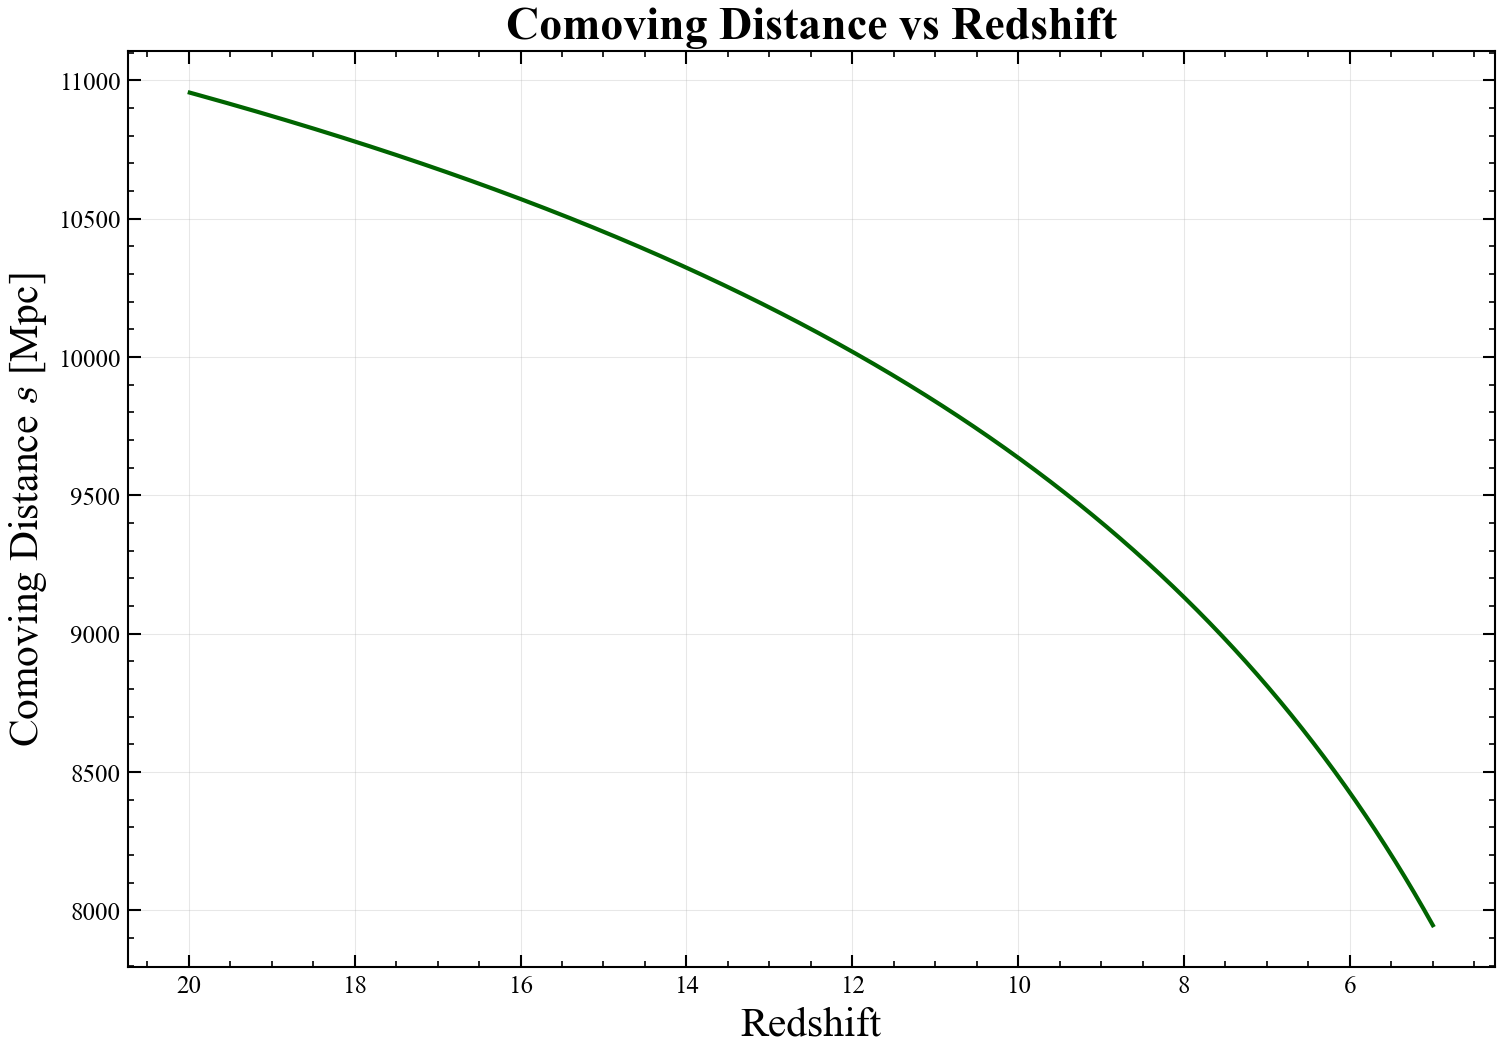

Saved: ds_vs_z


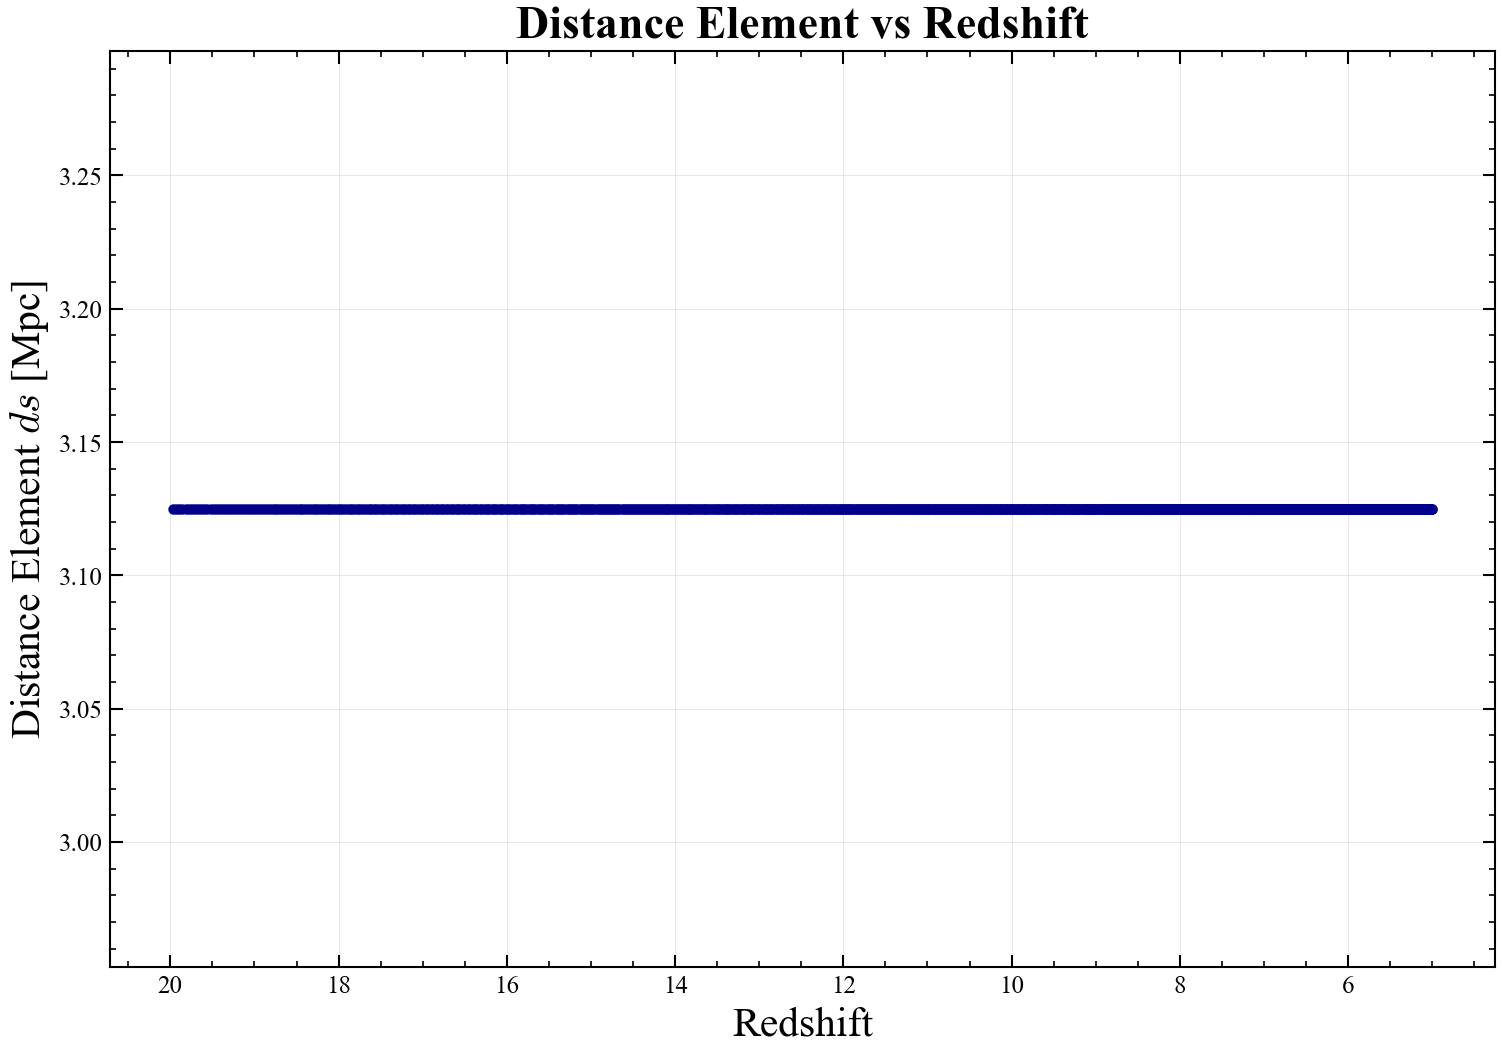

Saved: xe_vs_z


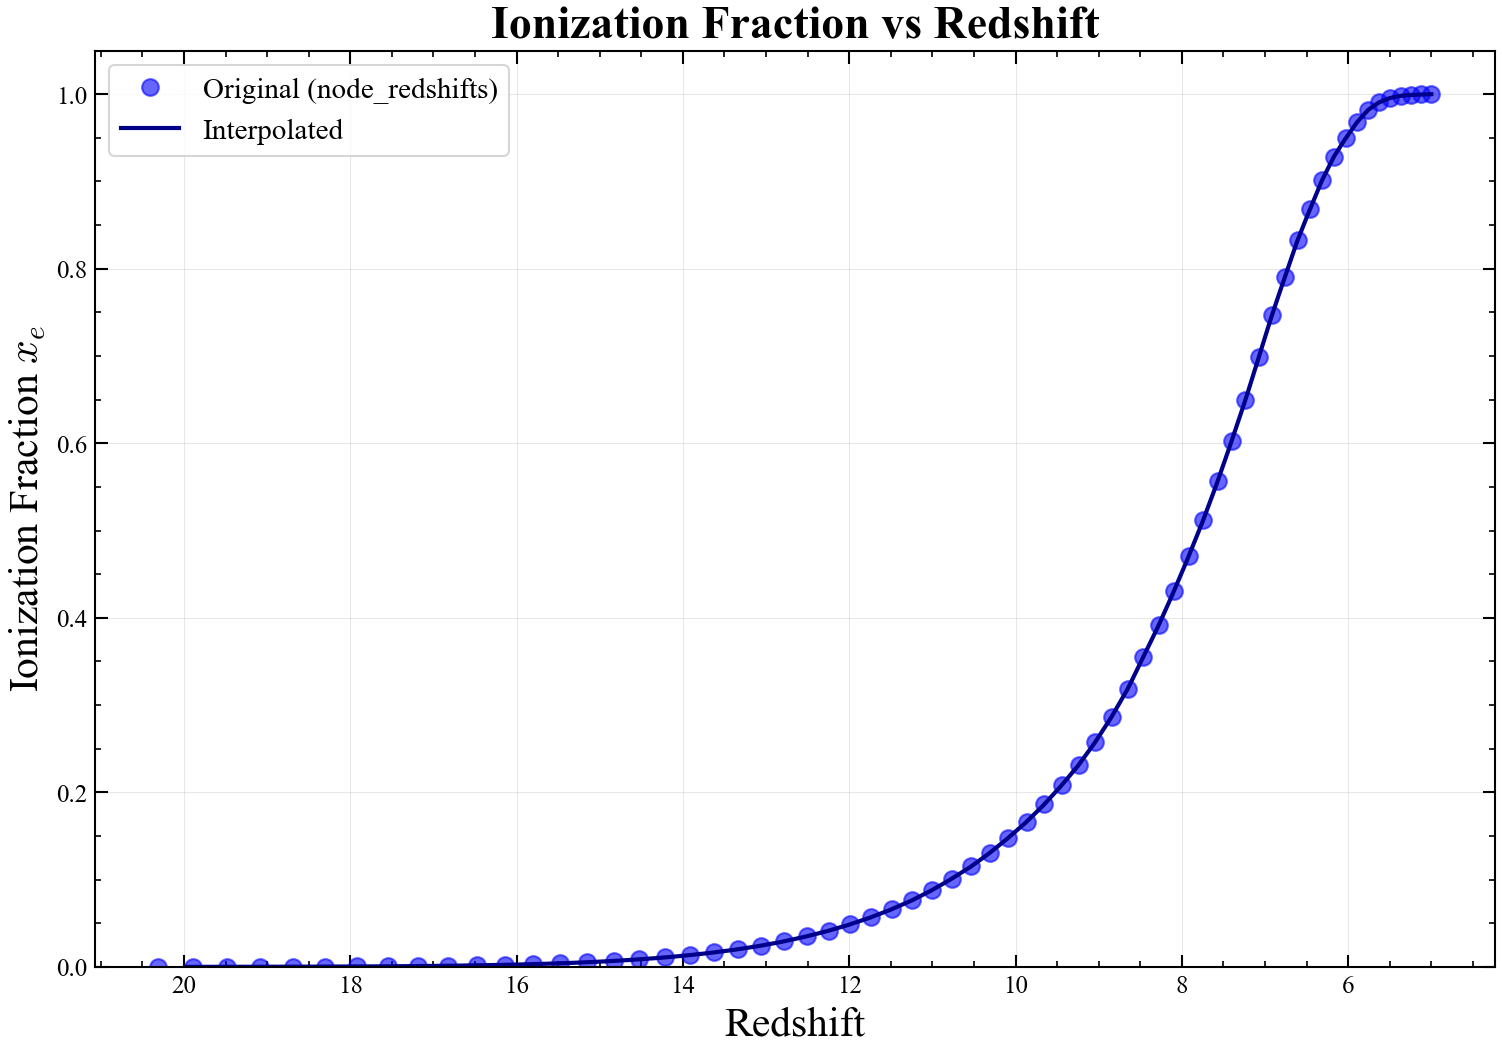

Saved: dtau_vs_z


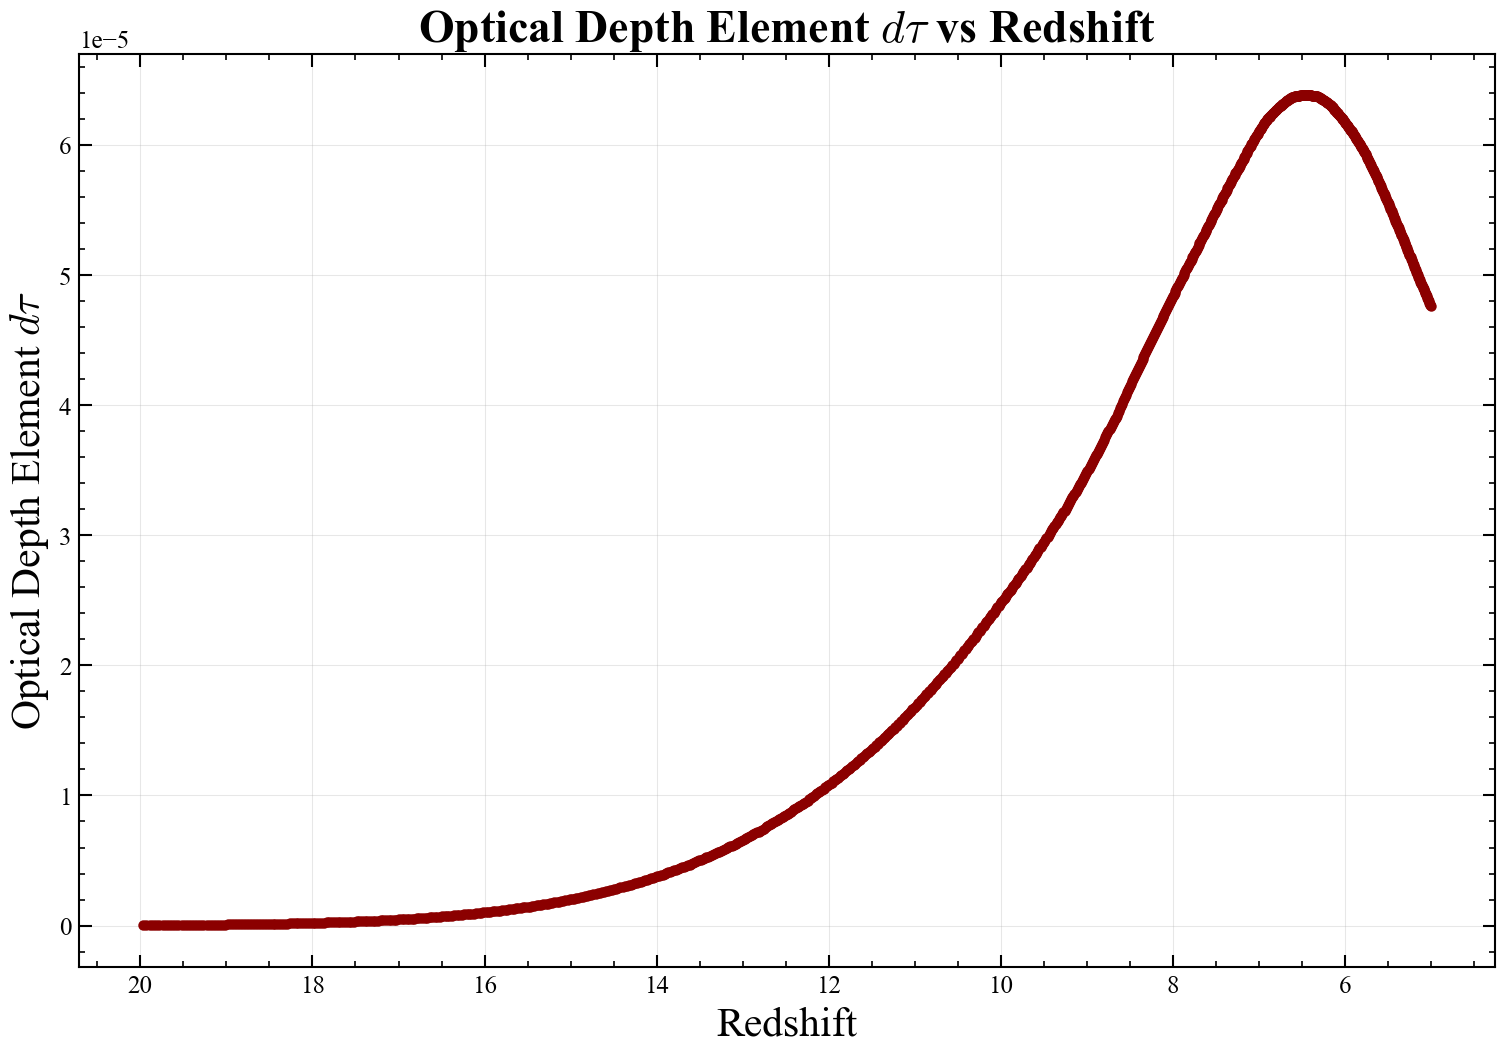

Saved: tau_vs_z


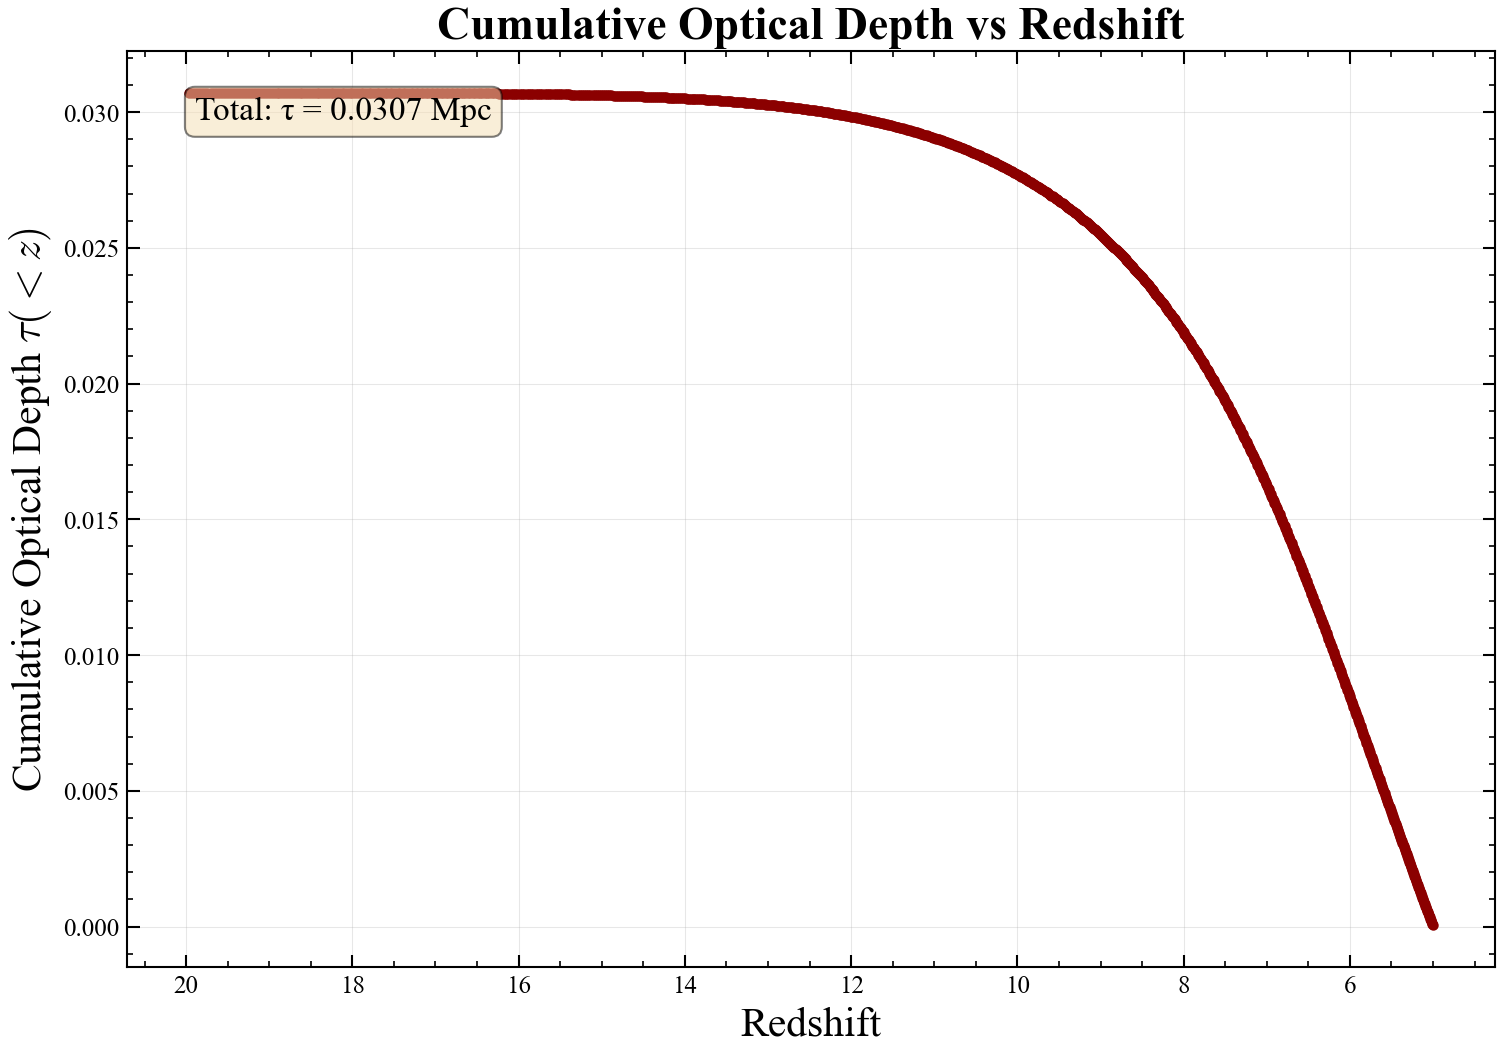


SUMMARY OF CALCULATIONS
Redshift range:           5.00 → 19.99
Comoving distance:        7946.5 Mpc → 10955.8 Mpc Mpc
Mean distance element:    3.125 Mpc Mpc
Ionization fraction:      0.0000 → 0.9999
Total optical depth:      τ = 0.030719 Mpc
Number of data points:    964


In [22]:
# =============================================================================
# COMPLETE CELL: Calculate and Plot s, ds, x_e, dτ, τ vs z
# Using interpolated x_e onto lightcone redshifts
# =============================================================================

# =============================================================================
# Step 1: Interpolate x_e onto lightcone redshifts
# =============================================================================

# Reverse node arrays to match lightcone order (low z → high z)
z_nodes_sorted = lightcone.node_redshifts[::-1]      # 5.0 → 20.3
xHI_nodes_sorted = lightcone.global_xH[::-1]
x_e_nodes_sorted = 1.0 - xHI_nodes_sorted

# Interpolate x_e onto lightcone redshift grid
x_e_interp = np.interp(red_axis, z_nodes_sorted, x_e_nodes_sorted)

print(f"\n=== INTERPOLATED IONIZATION FRACTION ===")
print(f"x_e range: [{x_e_interp.min():.4f}, {x_e_interp.max():.4f}]")

# =============================================================================
# Step 2: Extract/Calculate geometric quantities
# =============================================================================

# Comoving distance (already available)
s = pos_axis  # Comoving distance [Mpc]

# Distance element
ds = np.diff(s)  # [Mpc], length 963

# Midpoint values for integration
z_mid = 0.5 * (red_axis[:-1] + red_axis[1:])
x_e_mid = 0.5 * (x_e_interp[:-1] + x_e_interp[1:])

print(f"\n=== GEOMETRIC QUANTITIES ===")
print(f"s range: [{s.min():.1f}, {s.max():.1f}] Mpc")
print(f"ds: mean = {ds.mean():.3f} Mpc, std = {ds.std():.3f} Mpc")
print(f"Number of slices: {len(red_axis)}")

# =============================================================================
# Step 3: Calculate dτ and τ
# =============================================================================

# Physical constants (already defined earlier)
# prefactor = n_e0_Mpc3 * sigma_T_Mpc2  # Mpc^-1

# Calculate dτ
dtau = prefactor * x_e_mid * (1.0 + z_mid)**2 * ds

# Cumulative optical depth
tau = np.cumsum(dtau)
tau_total = tau[-1]

print(f"\n=== OPTICAL DEPTH ===")
print(f"dτ range: [{dtau.min():.6e}, {dtau.max():.6e}]")
print(f"Total τ: {tau_total:.6f}")
print(f"Integrated from z = {red_axis.min():.2f} → {red_axis.max():.2f}")

# =============================================================================
# PLOT 1: Comoving Distance s vs z
# =============================================================================

fig, ax = plt.subplots(1, 1, figsize=(10, 7), constrained_layout=True)
ax.plot(red_axis, s, '-', linewidth=2, color='darkgreen')
ax.set_xlabel('Redshift', fontsize=20)
ax.set_ylabel('Comoving Distance $s$ [Mpc]', fontsize=20)
ax.grid(True, alpha=0.3)
ax.invert_xaxis()

plot_name = "s_vs_z"
fig.savefig(f"{plot_dir}/{plot_name}.pdf", bbox_inches='tight')
ax.set_title('Comoving Distance vs Redshift', fontsize=22, fontweight='bold')
fig.savefig(f"{plot_dir}/{plot_name}.png", dpi=300, bbox_inches='tight')
print(f"Saved: {plot_name}")
plt.show()

# =============================================================================
# PLOT 2: Distance Element ds vs z
# =============================================================================

fig, ax = plt.subplots(1, 1, figsize=(10, 7), constrained_layout=True)
ax.plot(z_mid, ds, 'o-', linewidth=2, markersize=4, color='darkblue')
ax.set_xlabel('Redshift', fontsize=20)
ax.set_ylabel('Distance Element $ds$ [Mpc]', fontsize=20)
ax.grid(True, alpha=0.3)
ax.invert_xaxis()

plot_name = "ds_vs_z"
fig.savefig(f"{plot_dir}/{plot_name}.pdf", bbox_inches='tight')
ax.set_title('Distance Element vs Redshift', fontsize=22, fontweight='bold')
fig.savefig(f"{plot_dir}/{plot_name}.png", dpi=300, bbox_inches='tight')
print(f"Saved: {plot_name}")
plt.show()

# =============================================================================
# PLOT 3: Ionization Fraction x_e vs z
# =============================================================================

fig, ax = plt.subplots(1, 1, figsize=(10, 7), constrained_layout=True)
ax.plot(z_nodes_sorted, x_e_nodes_sorted, 'o', markersize=8, 
        label='Original (node_redshifts)', color='blue', alpha=0.6)
ax.plot(red_axis, x_e_interp, '-', linewidth=2, 
        label='Interpolated', color='darkblue')
ax.set_xlabel('Redshift', fontsize=20)
ax.set_ylabel(r'Ionization Fraction $x_e$', fontsize=20)
ax.set_ylim(0, 1.05)
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=14)
ax.invert_xaxis()

plot_name = "xe_vs_z"
fig.savefig(f"{plot_dir}/{plot_name}.pdf", bbox_inches='tight')
ax.set_title('Ionization Fraction vs Redshift', fontsize=22, fontweight='bold')
fig.savefig(f"{plot_dir}/{plot_name}.png", dpi=300, bbox_inches='tight')
print(f"Saved: {plot_name}")
plt.show()

# =============================================================================
# PLOT 4: Optical Depth Element dτ vs z
# =============================================================================

fig, ax = plt.subplots(1, 1, figsize=(10, 7), constrained_layout=True)
ax.plot(z_mid, dtau, 'o-', linewidth=2, markersize=4, color='darkred')
ax.set_xlabel('Redshift', fontsize=20)
ax.set_ylabel(r'Optical Depth Element $d\tau$', fontsize=20)
ax.grid(True, alpha=0.3)
ax.invert_xaxis()

plot_name = "dtau_vs_z"
fig.savefig(f"{plot_dir}/{plot_name}.pdf", bbox_inches='tight')
ax.set_title(r'Optical Depth Element $d\tau$ vs Redshift', fontsize=22, fontweight='bold')
fig.savefig(f"{plot_dir}/{plot_name}.png", dpi=300, bbox_inches='tight')
print(f"Saved: {plot_name}")
plt.show()

# =============================================================================
# PLOT 5: Cumulative Optical Depth τ vs z
# =============================================================================

fig, ax = plt.subplots(1, 1, figsize=(10, 7), constrained_layout=True)
ax.plot(z_mid, tau, 'o-', linewidth=2.5, markersize=4, color='darkred')
ax.set_xlabel('Redshift', fontsize=20)
ax.set_ylabel(r'Cumulative Optical Depth $\tau(<z)$', fontsize=20)
ax.grid(True, alpha=0.3)
ax.invert_xaxis()

# Add annotation for total tau
#ax.axhline(tau_total, color='gray', linestyle='--', alpha=0.5)
ax.text(0.05, 0.95, f'Total: τ = {tau_total:.4f}', 
        transform=ax.transAxes, fontsize=16, 
        verticalalignment='top', 
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plot_name = "tau_vs_z"
fig.savefig(f"{plot_dir}/{plot_name}.pdf", bbox_inches='tight')
ax.set_title('Cumulative Optical Depth vs Redshift', fontsize=22, fontweight='bold')
fig.savefig(f"{plot_dir}/{plot_name}.png", dpi=300, bbox_inches='tight')
print(f"Saved: {plot_name}")
plt.show()

# =============================================================================
# Summary
# =============================================================================

print(f"\n{'='*60}")
print(f"SUMMARY OF CALCULATIONS")
print(f"{'='*60}")
print(f"Redshift range:           {red_axis.min():.2f} → {red_axis.max():.2f}")
print(f"Comoving distance:        {s.min():.1f} → {s.max():.1f} Mpc")
print(f"Mean distance element:    {ds.mean():.3f} Mpc")
print(f"Ionization fraction:      {x_e_interp.min():.4f} → {x_e_interp.max():.4f}")
print(f"Total optical depth:      τ = {tau_total:.6f}")
print(f"Number of data points:    {len(red_axis)}")
print(f"{'='*60}")